In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
import json
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) 
print(count_control) 
print(count_swedd) 
print(count_prodromal)

125
132
72
80


In [3]:
PD_arrays=[]
replace_dict = {'F': '0','M':'1','Normal':'0','Slight':'1','Mild':'2','Moderate':'3','Severe':'4','T1-anatomical':'1','Processed':'1', 
               'BL':'0','V04':'1','V06':'2','V06':'3','V08':'4','V10':'5','NiFTI':'1','':'0','No':'0','Yes':'1','Stage 1':'1','Stage 2':'2','Stage 3':'3','Stage 4':'4'
               ,'On':'1','Off':'0','Stage 0':'0'}
for i in data_PD:
    j= i[21:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    PD_array = np.array(num_list)
    PD_arrays.append(PD_array)
PD_array = np.vstack(PD_arrays)

control_arrays = []
for i in data_control:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    control_array = np.array(num_list)
    control_arrays.append(control_array)
control_array = np.vstack(control_arrays)

swedd_arrays = []
for i in data_swedd:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    swedd_array = np.array(num_list)
    swedd_arrays.append(swedd_array)
swedd_array = np.vstack(swedd_arrays)

prodromal_arrays = []
for i in data_prodromal:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    prodromal_array = np.array(num_list)
    prodromal_arrays.append(prodromal_array)
prodromal_array = np.vstack(prodromal_arrays)

#加权算值
def weighted_sum(tensor):
    weights = [0.1, 0.3, 0.5 , 0.7]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [4]:
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()

pd_labels = torch.zeros(pd_tensor.shape[0], dtype=torch.long)
control_labels = torch.ones(control_tensor.shape[0], dtype=torch.long)
swedd_labels = torch.full((swedd_tensor.shape[0],), 3, dtype=torch.long)
prodromal_labels = torch.full((prodromal_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([pd_tensor, control_tensor, swedd_tensor,prodromal_tensor], dim=0)
y = torch.cat([pd_labels , control_labels  ,swedd_labels, prodromal_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
with torch.no_grad():
    pd_tensor = model(pd_tensor)
    control_tensor = model(control_tensor)
    swedd_tensor = model(swedd_tensor)
    prodromal_tensor = model(prodromal_tensor)
    
pd_tensor = weighted_sum(pd_tensor)
control_tensor = weighted_sum(control_tensor)
swedd_tensor = weighted_sum(swedd_tensor)
prodromal_tensor = weighted_sum(prodromal_tensor)

Epoch [10/50], Loss: 0.7876
Epoch [20/50], Loss: 0.6746
Epoch [30/50], Loss: 0.4986
Epoch [40/50], Loss: 0.5647
Epoch [50/50], Loss: 0.3999


In [5]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[4:22])
    return np.array(processed_data)
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [6]:
pd_data = preprocess_data(data_PD, replace_dict)
control_data = preprocess_data(data_control, replace_dict)
swedd_data = preprocess_data(data_swedd, replace_dict)
prodromal_data = preprocess_data(data_prodromal, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
pd_EHR = encode_categorical(pd_data, categorical_indices)
control_EHR = encode_categorical(control_data, categorical_indices)
swedd_EHR = encode_categorical(swedd_data, categorical_indices)
prodromal_EHR = encode_categorical(prodromal_data, categorical_indices)

pd_EHR = torch.from_numpy(pd_EHR).float()
control_EHR = torch.from_numpy(control_EHR).float()
swedd_EHR = torch.from_numpy(swedd_EHR).float()
prodromal_EHR = torch.from_numpy(prodromal_EHR).float()

linear_layer = nn.Linear(18, 16)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

linear_layer = nn.Linear(16, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd.EHR--->', pd_EHR.shape)
print('control.EHR--->', control_EHR.shape)
print('swedd.EHR--->', swedd_EHR.shape)
print('prodromal.EHR--->', prodromal_EHR.shape)

pd.EHR---> torch.Size([125, 1])
control.EHR---> torch.Size([132, 1])
swedd.EHR---> torch.Size([72, 1])
prodromal.EHR---> torch.Size([80, 1])


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
def center_crop_3d(tensor, size):
    depth, height, width = tensor.shape
    target_depth, target_height, target_width = size

    start_depth = (depth - target_depth) // 2
    start_height = (height - target_height) // 2
    start_width = (width - target_width) // 2

    end_depth = start_depth + target_depth
    end_height = start_height + target_height
    end_width = start_width + target_width

    return tensor[start_depth:end_depth, start_height:end_height, start_width:end_width]

In [9]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib

# 你的 NiiDataset，务必用这版
class NiiDataset(Dataset):
    def __init__(self, file_list_or_folder):
        if isinstance(file_list_or_folder, list):
            self.file_list = file_list_or_folder
        elif isinstance(file_list_or_folder, str):
            folder_path = file_list_or_folder
            self.file_list = [os.path.join(folder_path, filename)
                              for filename in os.listdir(folder_path)
                              if filename.endswith('.nii') or filename.endswith('.nii.gz')]
        else:
            raise ValueError("参数应为list或str")
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        img = nib.load(file_path)
        img_data = img.get_fdata()
        img_tensor = torch.from_numpy(img_data).float()
        cropped_tensor = center_crop_3d(img_tensor, (64, 64, 64))   # 你的裁剪函数
        input_tensor = cropped_tensor.unsqueeze(0)
        return input_tensor

# 1. 严格用csv顺序生成影像路径
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD影像数量: {len(pd_img_paths)}')
print(f'Control影像数量: {len(control_img_paths)}')
print(f'SWEDD影像数量: {len(swedd_img_paths)}')
print(f'Prodromal影像数量: {len(prodromal_img_paths)}')

batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)

# 2. 用于影像特征提取
# PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)

PD影像数量: 125
Control影像数量: 132
SWEDD影像数量: 72
Prodromal影像数量: 80
PD nii shape---> torch.Size([125, 1])
control nii shape---> torch.Size([132, 1])
prodromal nii shape---> torch.Size([80, 1])
swedd nii shape---> torch.Size([72, 1])


In [10]:
# ===== 读取 DementiaKG (128维) 实体向量 =====
pd_df        = pd.read_csv('PD1.csv')
control_df   = pd.read_csv('control.csv')
prodromal_df = pd.read_csv('prodromal.csv')
swedd_df     = pd.read_csv('swedd.csv')

# 1. 修改文件名 (请确保你的 128维 npy 文件名是正确的，这里假设叫 ppmi_kg_embeddings.npy)
ENTITY_EMB_NPY = "ppmi_kg_embeddings.npy"  # <--- 修改这里：你的128维向量文件
ENTITY2ID_JSON  = "ppmi_kg_entity2id.json"  # <--- 修改这里：构建脚本生成的json文件

# 2. 修改读取映射表的逻辑 (从 TXT 改为 JSON)
print(f"正在加载映射表: {ENTITY2ID_JSON} ...")
with open(ENTITY2ID_JSON, "r", encoding="utf-8") as f:
    entity2id = json.load(f)  # 直接用 json.load 读取

# 3. 加载实体嵌入矩阵
# 注意：这里加载后的 shape 应该是 [N, 128]
entity_embeddings = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()
print(f"KG Embeddings Shape: {entity_embeddings.shape}") # 打印确认一下是不是 (N, 128)

# 4. 把 id (int) 映射到 行号 (index)
# 新构建脚本生成的 json value 已经是 int 类型的 ID 了，通常不需要再转换，但为了保险起见保持逻辑：
# 如果 json 里 value 是 0, 1, 2... 这种连续整数，其实 id_to_index 就是 value 本身。
# 但为了兼容你的 DistMultExtract 类，我们保留 id_to_index 字典。
id_to_index = {str(v): v for k, v in entity2id.items()} 

# 5. DistMultExtract 类 (保持不变)
class DistMultExtract:
    def __init__(self, entity_embeddings, entity2id, id_to_index):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = id_to_index

    def get_entity_embedding(self, entity):
        # 这里的 entity 是 csv 里的症状字符串 (如 "Tremor")
        # 新构建脚本生成的 entity2id 里的 key 应该是 "PrimeKG:Tremor" 或 "Tremor" (取决于构建脚本)
        # 根据 build_ppmi_DementiaKG.ipynb 的输出，key 可能是 "PrimeKG:Tremor"
        # 所以这里可能需要加一个前缀尝试
        
        target_key = entity
        # 尝试直接查找
        if target_key in self.entity2id:
            pass
        # 尝试加前缀查找 (构建脚本里加了 PrimeKG: 前缀)
        elif f"PrimeKG:{entity}" in self.entity2id:
            target_key = f"PrimeKG:{entity}"
        elif f"Concept:{entity}" in self.entity2id:
            target_key = f"Concept:{entity}"
            
        if target_key in self.entity2id:
            ent_id = self.entity2id[target_key]
            # 如果 ent_id 已经是 int，直接用；如果是 str，转 int
            row_idx = int(ent_id) 
            return self.entity_embeddings[row_idx]
        else:
            # 找不到就返回 0 向量或者跳过，这里为了防止报错，可以打印一下
            # raise KeyError(f"Entity {entity} not found...") 
            return torch.zeros(entity_embeddings.shape[1]) # 返回全0向量兜底

# 6. 初始化提取器
kg_extractor = DistMultExtract(entity_embeddings, entity2id, id_to_index)

# 7. get_embeddings 函数 (保持不变)
def get_embeddings(df, extractor, nii_folder):
    embeddings_list = []
    skipped_rows = 0
    for _, row in df.iterrows():
        nii_file = row.iloc[1]
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            skipped_rows += 1
            continue
        row_embeddings = []
        # 遍历症状列
        for col in df.columns[7:]:
            entity = str(row[col])
            # 过滤掉无意义的值
            if entity != '0' and entity != 'nan' and entity != '':
                emb = extractor.get_entity_embedding(entity)
                if not torch.equal(emb, torch.zeros(entity_embeddings.shape[1])): # 只要不是全0兜底
                    row_embeddings.append(emb)
        
        # 新 KG 里有 Patient:XXXX 节点，保留下面这段：
        filename = f"Patient:{int(row['Subject'])}" # 新格式通常有 Patient: 前缀
        emb_subj = extractor.get_entity_embedding(filename)
        if not torch.equal(emb_subj, torch.zeros(entity_embeddings.shape[1])):
             row_embeddings.append(emb_subj)

        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
            embeddings_list.append(mean_embedding)
        else:
            # 如果没有找到任何症状，补一个全0
            embeddings_list.append(torch.zeros(entity_embeddings.shape[1]))
            
    if not embeddings_list:
        return torch.empty((0, entity_embeddings.shape[1]))
    return torch.stack(embeddings_list)

# 8. 获取嵌入
# 注意：这里会花一点时间
pd_transe        = get_embeddings(pd_df,        kg_extractor, 'PD')
control_transe   = get_embeddings(control_df,   kg_extractor, 'Control')
prodromal_transe = get_embeddings(prodromal_df, kg_extractor, 'Prodromal')
swedd_transe     = get_embeddings(swedd_df,     kg_extractor, 'SWEDD')

print(pd_transe.shape, control_transe.shape, prodromal_transe.shape, swedd_transe.shape)
# 预期输出: (125, 128) ... 也就是第二维应该是 128

正在加载映射表: ppmi_kg_entity2id.json ...
KG Embeddings Shape: torch.Size([1079, 128])
torch.Size([125, 128]) torch.Size([132, 128]) torch.Size([80, 128]) torch.Size([72, 128])


In [11]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [12]:
# ------- 重新拼接特征 + 构造 DataLoader ------- #
transe_embed_dim = 128   # DistMult 嵌入维度

X_pd = torch.cat([pd_EHR, PD_output.cpu(), pd_tensor, pd_transe], dim=1)
X_control = torch.cat([control_EHR, control_output.cpu(), control_tensor, control_transe], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output.cpu(), swedd_tensor, swedd_transe], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output.cpu(), prodromal_tensor, prodromal_transe], dim=1)

y_pd = torch.zeros(len(X_pd))          # 标签顺序 PD=0
y_control = torch.ones(len(X_control)) # Control=1
y_swedd = torch.full((len(X_swedd),), 2)
y_prodromal = torch.full((len(X_prodromal),), 3)

X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

features = X[:, :-transe_embed_dim]
kg_embed = X[:, -transe_embed_dim:]





from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, kg_train, kg_test = train_test_split(
    features.detach().cpu().numpy(),          # ←★ 改这里
    y.cpu().numpy(),
    kg_embed.detach().cpu().numpy(),          # ←★ 以及这里
    test_size=0.20, stratify=y.cpu().numpy(), random_state=32
)

X_train, X_val, y_train, y_val, kg_train, kg_val = train_test_split(
    X_train, y_train, kg_train,
    test_size=0.20, stratify=y_train, random_state=30
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
kg_train_tensor = torch.FloatTensor(kg_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
kg_val_tensor = torch.FloatTensor(kg_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
kg_test_tensor = torch.FloatTensor(kg_test).to(device)

from torch.utils.data import TensorDataset, DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, kg_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   kg_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  kg_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)
print("DataLoaders ready:", len(train_loader), len(val_loader), len(test_loader))
# ------------------------------------------- #


DataLoaders ready: 9 3 3


In [13]:
embed_dim        = 128
transe_embed_dim = 128          # 名字不改省事；实际装的是 DistMult
num_epochs       = 200
batch_size       = 32
learning_rate    = 1e-5
weight_decay     = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# KGMultiModalTransformer 保持不变，只是继续把 transe_embed_dim=32 传进去
model = KGMultiModalTransformer(embed_dim=embed_dim,
                                transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/200, Train Loss: 1.5142, Train AUC: 0.4421  test Loss: 1.3708, test AUC: 0.5439
Epoch 2/200, Train Loss: 1.4040, Train AUC: 0.4967  test Loss: 1.3655, test AUC: 0.5703


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 3/200, Train Loss: 1.3873, Train AUC: 0.5070  test Loss: 1.3536, test AUC: 0.5879
Epoch 4/200, Train Loss: 1.4478, Train AUC: 0.5236  test Loss: 1.3372, test AUC: 0.6029


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

Epoch 55/200, Train Loss: 0.9123, Train AUC: 0.8558  test Loss: 0.9035, test AUC: 0.8702
Epoch 56/200, Train Loss: 0.9158, Train AUC: 0.8583  test Loss: 0.8983, test AUC: 0.8717


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 57/200, Train Loss: 1.0644, Train AUC: 0.8553  test Loss: 0.8977, test AUC: 0.8769
Epoch 58/200, Train Loss: 0.9751, Train AUC: 0.8650  test Loss: 0.8886, test AUC: 0.8695


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 59/200, Train Loss: 0.9290, Train AUC: 0.8597  test Loss: 0.8838, test AUC: 0.8741
Epoch 60/200, Train Loss: 0.9618, Train AUC: 0.8568  test Loss: 0.8776, test AUC: 0.8704
Epoch 61/200, Train Loss: 0.9091, Train AUC: 0.8791  test Loss: 0.8726, test AUC: 0.8690
Epoch 62/200, Train Loss: 0.9781, Train AUC: 0.8648  test Loss: 0.8707, test AUC: 0.8722
Epoch 63/200, Train Loss: 0.9199, Train AUC: 0.8665  test Loss: 0.8780, test AUC: 0.8760
Epoch 64/200, Train Loss: 0.8959, Train AUC: 0.8752  test Loss: 0.8761, test AUC: 0.8765
Epoch 65/200, Train Loss: 0.9180, Train AUC: 0.8754  test Loss: 0.8712, test AUC: 0.8700
Epoch 66/200, Train Loss: 0.9470, Train AUC: 0.8770  test Loss: 0.8633, test AUC: 0.8729
Epoch 67/200, Train Loss: 0.9456, Train AUC: 0.8740  test Loss: 0.8660, test AUC: 0.8768
Epoch 68/200, Train Loss: 0.9822, Train AUC: 0.8733  test Loss: 0.8636, test AUC: 0.8766
Epoch 69/200, Train Loss: 0.9902, Train AUC: 0.8673  test Loss: 0.8846, test AUC: 0.8834
Epoch 70/200, Train L

In [14]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.6615
Precision: 0.6617
Recall:    0.5912
F1 Score:  0.5835
AUC-ROC:   0.9206


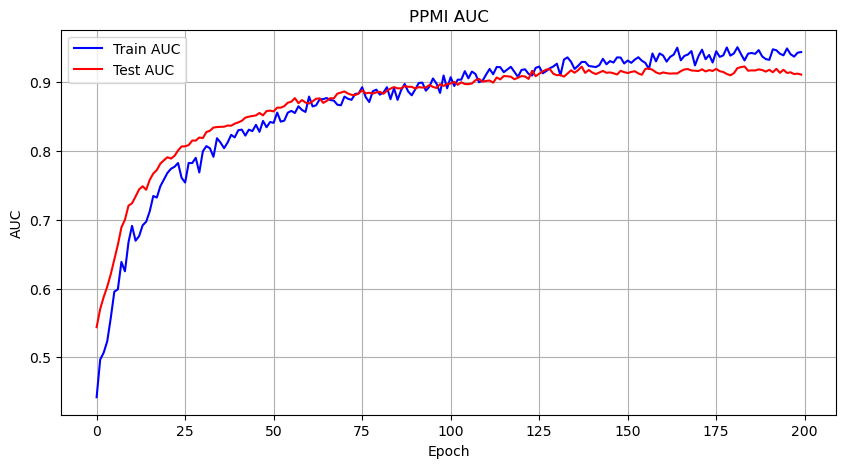

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

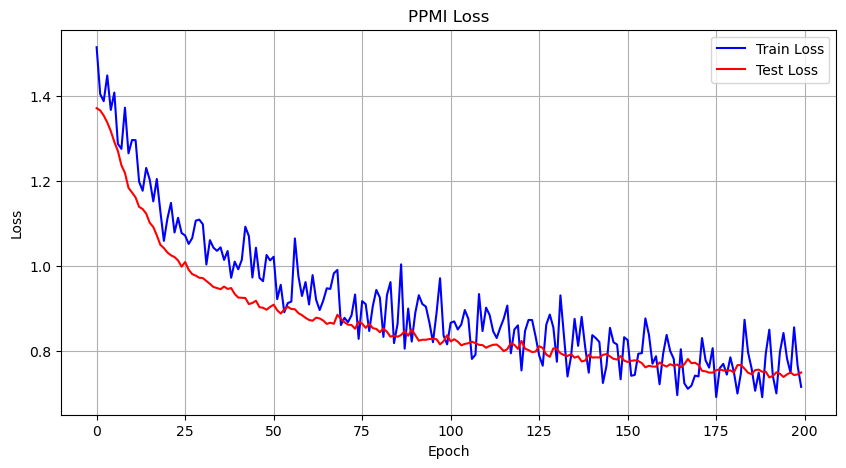

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()